In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import skimage

from lamina.loading.album import Album
from PIL import Image

In [2]:
album = Album(
    format=["png", "bmp", "tif"],
    image_store=r"/mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy"
)

In [3]:
album.make_album()

Could not open /mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy/Michael Popcorn AFM/20191012 1 2/Pop 3.bmp.


In [4]:
photos = album.photos

In [5]:
random_image = random.choice(sum([list(photos[_].values()) for _ in photos.keys()], start=list([])))

In [6]:
random_image.format

'PNG'

In [7]:
shape = random_image.size

In [8]:
mode = random_image.mode

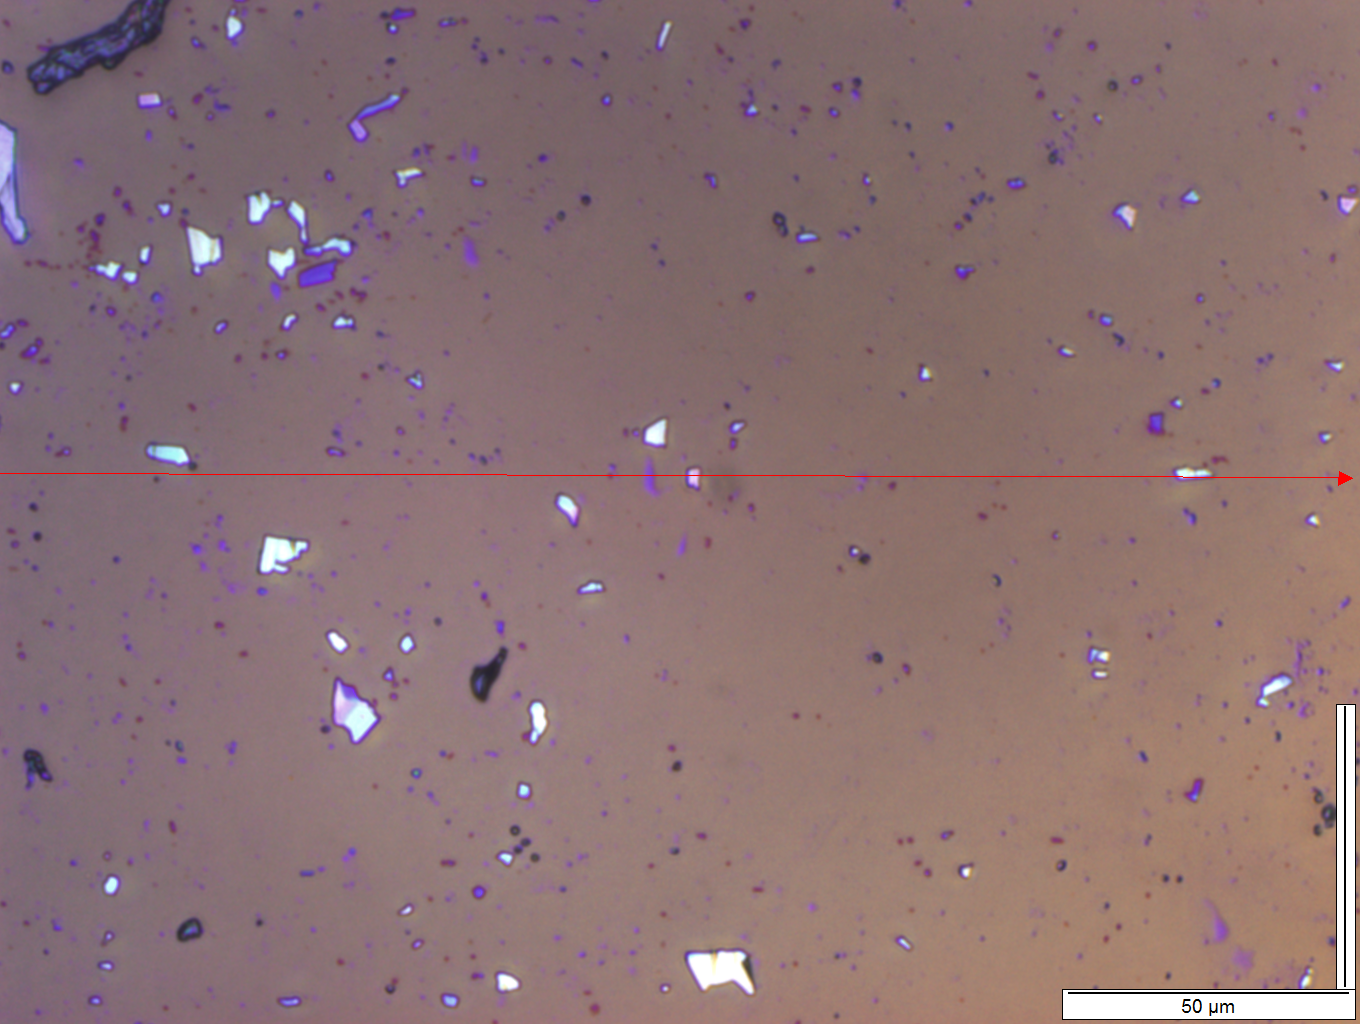

In [9]:
random_image

### Masking all pixels that are in the labels and arrows

In [10]:
max_8_bit = 2 ** 8 - 1
min_8_bit = 0

black = [min_8_bit, min_8_bit, min_8_bit]
white = [max_8_bit, max_8_bit, max_8_bit]
red = [max_8_bit, min_8_bit, min_8_bit]
blue = [min_8_bit, min_8_bit, max_8_bit]

# Making the image mask.
mask_image = np.array(random_image)

# Checking for the colors we want to ignore in the original image.
black_mask = np.all(mask_image == black, axis=2)
white_mask = np.all(mask_image == white, axis=2)
red_mask = np.all(mask_image == red, axis=2)
blue_mask = np.all(mask_image == blue, axis=2)

label_mask = black_mask | white_mask | red_mask | blue_mask

### Changing image to grayscale for easier thresholding

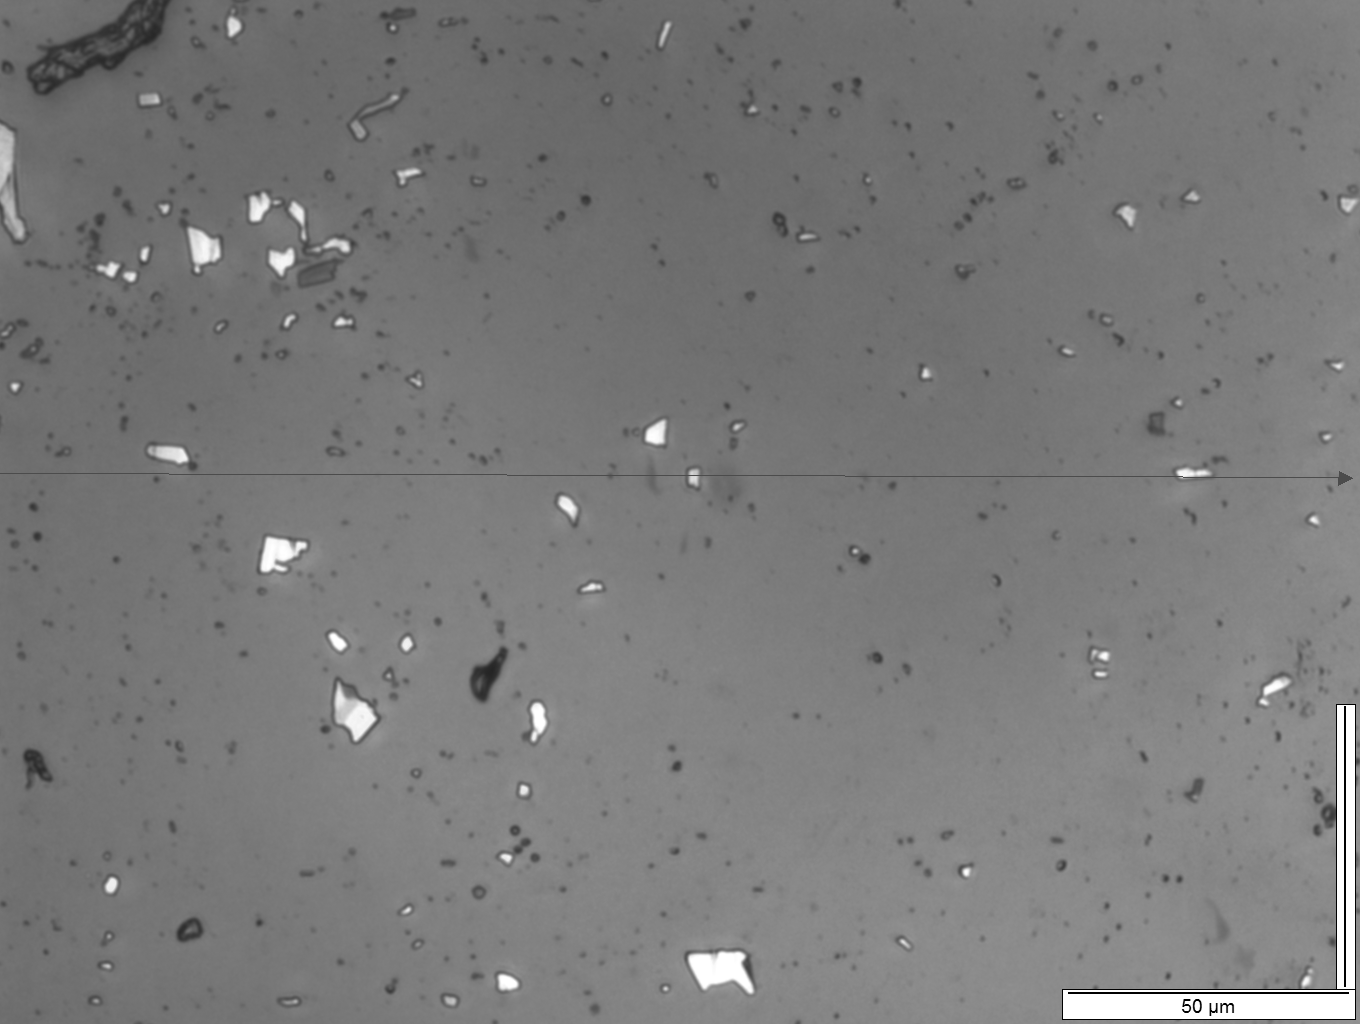

In [11]:
grayscale_image = random_image.convert("L")
grayscale_image

In [12]:
grayscale = np.array(grayscale_image)

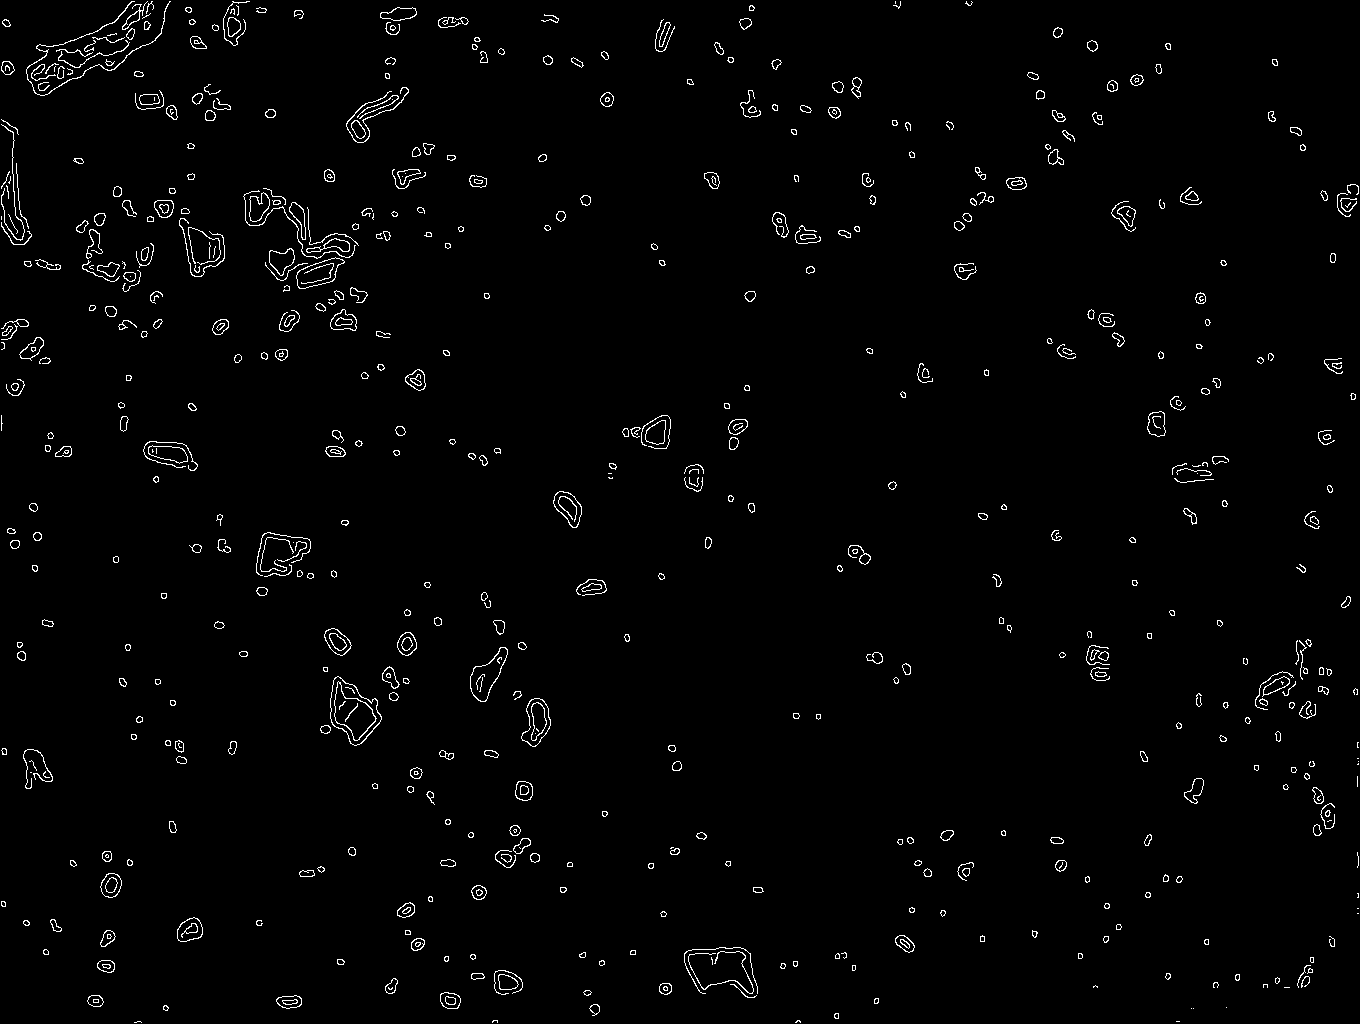

In [13]:
edges = skimage.feature.canny(grayscale, sigma=0.5, mask=~label_mask)
edges_image = Image.fromarray((edges * 255).astype(np.uint8))
edges_image

### Attempt to connect all lines (maybe try using a Hough filter) before using scipy.ndimage.binary_fill_holes.